In [1]:
import sys
print(sys.executable)

c:\Users\Nihit Reddy\AppData\Local\Programs\Python\Python311\python.exe


In [2]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

In [3]:
BASE_PATH = "train"

IMAGE_DIR = os.path.join(BASE_PATH, "image")
ANNO_DIR  = os.path.join(BASE_PATH, "annos")

print("Total Images:", len(os.listdir(IMAGE_DIR)))
print("Total Annotations:", len(os.listdir(ANNO_DIR)))

Total Images: 191961
Total Annotations: 191961


In [4]:
sample_image_name = os.listdir(IMAGE_DIR)[0]

image_path = os.path.join(IMAGE_DIR, sample_image_name)
anno_path  = os.path.join(
    ANNO_DIR,
    sample_image_name.replace(".jpg", ".json")
)

# Load image
image = Image.open(image_path).convert("RGB")

# Load annotation
with open(anno_path) as f:
    annotation = json.load(f)

print(annotation.keys())

dict_keys(['item2', 'source', 'pair_id', 'item1'])


In [5]:
boxes = []
labels = []

for key in annotation:
    if key.startswith("item"):
        item = annotation[key]
        boxes.append(item["bounding_box"])
        labels.append(item["category_id"])

boxes = np.array(boxes)
labels = np.array(labels)

print("Boxes:\n", boxes)
print("Labels:\n", labels)

Boxes:
 [[249 423 466 623]
 [  0  29 466 622]]
Labels:
 [8 1]


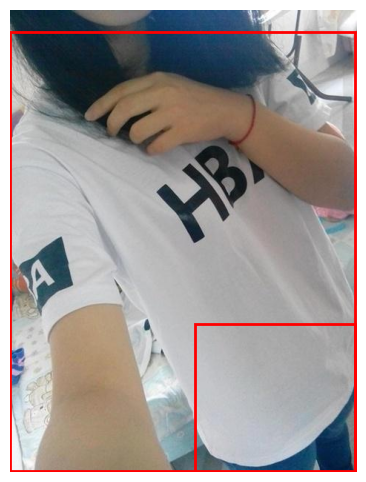

In [6]:
plt.figure(figsize=(6,6))
plt.imshow(image)

for box in boxes:
    x1, y1, x2, y2 = box
    plt.gca().add_patch(
        plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            edgecolor='red',
            linewidth=2
        )
    )

plt.axis("off")
plt.show()

In [7]:
transform = transforms.ToTensor()

image_tensor = transform(image)

boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.int64)

target = {
    "boxes": boxes_tensor,
    "labels": labels_tensor
}

print("Image shape:", image_tensor.shape)
print("Target:", target)

Image shape: torch.Size([3, 624, 468])
Target: {'boxes': tensor([[249., 423., 466., 623.],
        [  0.,  29., 466., 622.]]), 'labels': tensor([8, 1])}


In [14]:
class ApparelDataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, anno_dir, transform=None):
        self.image_dir = image_dir
        self.anno_dir = anno_dir
        self.images = sorted(os.listdir(image_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        
        img_path = os.path.join(self.image_dir, img_name)
        anno_path = os.path.join(
            self.anno_dir,
            img_name.replace(".jpg", ".json")
        )
        
        image = Image.open(img_path).convert("RGB")
        
        with open(anno_path) as f:
            annotation = json.load(f)
        
        boxes = []
        labels = []
        
        for key in annotation:
            if key.startswith("item"):
                item = annotation[key]
                boxes.append(item["bounding_box"])
                labels.append(item["category_id"])
        
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx])
        }
        
        if self.transform:
            image = self.transform(image)
        
        return image, target

In [15]:
dataset = ApparelDataset(IMAGE_DIR, ANNO_DIR, transform=transforms.ToTensor())

def collate_fn(batch):
    return tuple(zip(*batch))

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

images, targets = next(iter(loader))

print("Batch size:", len(images))
print("First target:", targets[0])

Batch size: 4
First target: {'boxes': tensor([[321., 316., 477., 470.],
        [258., 132., 453., 343.]]), 'labels': tensor([7, 1]), 'image_id': tensor([171827])}


In [16]:
from collections import Counter

category_counter = Counter()

for file in os.listdir(ANNO_DIR):
    with open(os.path.join(ANNO_DIR, file)) as f:
        annotation = json.load(f)
    
    for key in annotation:
        if key.startswith("item"):
            category_counter[annotation[key]["category_id"]] += 1

print("Category Frequencies:")
print(category_counter)

Category Frequencies:
Counter({1: 71645, 8: 55387, 7: 36616, 2: 36064, 9: 30835, 12: 17949, 10: 17211, 5: 16095, 4: 13457, 11: 7907, 13: 6492, 6: 1985, 3: 543})


In [17]:
top5 = [cat for cat, _ in category_counter.most_common(5)]
print("Top 5 Categories:", top5)

Top 5 Categories: [1, 8, 7, 2, 9]


In [18]:
class ApparelDataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, anno_dir, top_categories, transform=None):
        self.image_dir = image_dir
        self.anno_dir = anno_dir
        self.images = sorted(os.listdir(image_dir))
        self.transform = transform
        self.top_categories = top_categories

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        anno_path = os.path.join(
            self.anno_dir,
            img_name.replace(".jpg", ".json")
        )

        image = Image.open(img_path).convert("RGB")

        with open(anno_path) as f:
            annotation = json.load(f)

        boxes = []
        labels = []

        for key in annotation:
            if key.startswith("item"):
                item = annotation[key]
                cat = item["category_id"]

                if cat in self.top_categories:
                    boxes.append(item["bounding_box"])
                    labels.append(cat)

        # Skip images with no valid objects
        if len(boxes) == 0:
            return self.__getitem__((idx + 1) % len(self.images))

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx])
        }

        if self.transform:
            image = self.transform(image)

        return image, target

In [19]:
filtered_counter = Counter()

for file in os.listdir(ANNO_DIR):
    with open(os.path.join(ANNO_DIR, file)) as f:
        annotation = json.load(f)
    
    for key in annotation:
        if key.startswith("item"):
            cat = annotation[key]["category_id"]
            if cat in top5:
                filtered_counter[cat] += 1

print(filtered_counter)

Counter({1: 71645, 8: 55387, 7: 36616, 2: 36064, 9: 30835})


In [20]:
total = sum(filtered_counter.values())

class_weights = {
    cat: total / filtered_counter[cat]
    for cat in filtered_counter
}

print(class_weights)

{8: 4.162474948995252, 1: 3.217907739549166, 2: 6.392718500443656, 9: 7.476795848873034, 7: 6.29634585973345}


In [21]:
top5 = sorted(filtered_counter.keys())

label_map = {cat: i+1 for i, cat in enumerate(top5)}

print("Label Map:", label_map)

Label Map: {1: 1, 2: 2, 7: 3, 8: 4, 9: 5}


In [23]:
class ApparelDataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, anno_dir, top_categories, label_map, transform=None):
        self.image_dir = image_dir
        self.anno_dir = anno_dir
        self.images = sorted(os.listdir(image_dir))
        self.top_categories = top_categories
        self.label_map = label_map
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        anno_path = os.path.join(
            self.anno_dir,
            img_name.replace(".jpg", ".json")
        )

        image = Image.open(img_path).convert("RGB")

        with open(anno_path) as f:
            annotation = json.load(f)

        boxes = []
        labels = []

        for key in annotation:
            if key.startswith("item"):
                item = annotation[key]
                cat = item["category_id"]

                if cat in self.top_categories:
                    boxes.append(item["bounding_box"])
                    labels.append(self.label_map[cat])

        # Skip images with no valid objects
        if len(boxes) == 0:
            return self.__getitem__((idx + 1) % len(self.images))

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx])
        }

        if self.transform:
            image = self.transform(image)

        return image, target

In [24]:
train_dataset = ApparelDataset(
    image_dir="train/image",
    anno_dir="train/annos",
    top_categories=top5,
    label_map=label_map,
    transform=transforms.ToTensor()
)

val_dataset = ApparelDataset(
    image_dir="validation/image",
    anno_dir="validation/annos",
    top_categories=top5,
    label_map=label_map,
    transform=transforms.ToTensor()
)

In [26]:
from torch.utils.data import DataLoader
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Train size: 191961
Validation size: 32153


In [27]:
import json

with open("top5.json", "w") as f:
    json.dump(top5, f)

with open("label_map_classification.json", "w") as f:
    json.dump(label_map, f)

print("Saved top5 and label_map")

Saved top5 and label_map
